<a href="https://colab.research.google.com/github/geraldinemarriaga3-osss/Ladb_mobility_economy_project/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
df= pd.read_csv ("/datasets/plans.csv")
df= pd.read_csv("/datasets/users_latam.csv")
df= pd.read_csv("/datasets/usage.csv")
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans. head (5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head (5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print("users", users.isna().sum()) # Cantidad de valores nulos
print("users", users.isna().mean())# Proporción de valores nulos

users user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
users user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print("usage", usage.isna().sum())

usage id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?

- *
*En el df users hay valores faltantes en las columnas de city (469) que representan un proporción del 11% y en la columna de Churn_date (3534) representando una proporción del 88%.**

- **Para el df "usage" hay valores faltantes en la columna "date" de (50) que representa una proporción del 0.125% y en la columna "duration" de (22.076) proporción del 55% y la ultima columna es "length" (17.896) que representa el 44.7%**

-
- Indica qué harías: ¿imputar, eliminar, ignorar?

- **En la columna "churn_date" como tiene más del 80% del proporción voy a ignorar los datos, ya que indica que los clientes aún no se han ido, cuentan con el plan activo; y para la columna "city" procederé a investigar si puedo imputar o dejar como nulos, ya que no representa un proporción muy grande**

- **La columna "date" dejaré como un caso de nulos, en "duration" y "lenght" investigar para imputar o dejar como nulos**


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
print ("users", users.describe())

users             user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` ... observo un desviación estandar baja, osea poca variabilidad y los min y max no están distantes por lo cual su rango no es amplio, en general hay un comportamiento normal de la columna.  
- La columna `age` el promedio de edad es de 33, el valor min de -999 no es tipico para este tipo de columna, por lo cual representaría un outlier, las demás datos estan entre el rango real de cifras, como que el máximo de edad pueda ser 79 años.

In [ ]:
# explorar columnas numéricas de usage
print ("usage", usage.describe())

usage                 id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` tiene un comportamiento normal de los datos, por ejemplo su promedio es la mitad de los datos, una desviación estandar normal y valos min y max dentro del rango. En `user_id` observo un desviación estandar baja, osea poca variabilidad y los min y max no están distantes por lo cual su rango no es amplio, en general hay un comportamiento normal de la columna.
- Las columnas`duration` y `lenght` al tener valores faltantes pueden estar representando sesgos hacia a la derecha ya que se observa que sus valores min inician desde cero (0) y std baja.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users['city'].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

- La columna `city` Hay 6 ciudades, siendo Bogotá con mayor registro de 808, seguida de Ciudad de México con 730 y valores invalidos (?) de 96 registros.
- La columna `plan` hay 2595 basico y 1405 premium.

In [ ]:
# explorar columna categórica de usage
usage['type'].value_counts ()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` tiene 2 categorias: texto con 22.092 registros y call de 17.908 registros.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels? ** Encontré valores invalidos en la columna de "city" de 96 registros con signo (?)
- ¿Qué acción tomarías?  Al ser un sentinels de pocos registros lo trataré como NaN, para que lo pueda contar e ignorar y no me afecte mi registro de columna.  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] =pd.to_datetime(users['reg_date'])

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])

In [ ]:
# Revisar los años presentes en `reg_date` de users
print (users['reg_date'])

0      2022-01-01 00:00:00.000000000
1      2022-01-01 06:34:17.914478619
2      2022-01-01 13:08:35.828957239
3      2022-01-01 19:42:53.743435858
4      2022-01-02 02:17:11.657914478
                    ...             
3995   2024-12-29 21:42:48.342085520
3996   2024-12-30 04:17:06.256564144
3997   2024-12-30 10:51:24.171042768
3998   2024-12-30 17:25:42.085521392
3999   2024-12-31 00:00:00.000000000
Name: reg_date, Length: 4000, dtype: datetime64[ns]


En `reg_date`, ...veo que toma registros de fechas desde el año 2022 hasta el 2024.

In [ ]:
# Revisar los años presentes en `date` de usage
print (usage['date'])

0       2024-01-01 00:00:00.000000000
1       2024-01-01 00:06:30.969774244
2       2024-01-01 00:13:01.939548488
3       2024-01-01 00:19:32.909322733
4       2024-01-01 00:26:03.879096977
                     ...             
39995   2024-06-29 23:33:56.120903022
39996   2024-06-29 23:40:27.090677266
39997   2024-06-29 23:46:58.060451510
39998   2024-06-29 23:53:29.030225754
39999   2024-06-30 00:00:00.000000000
Name: date, Length: 40000, dtype: datetime64[ns]


En `date`, observo que toma fechas desde 01 enero del 2024 hasta 30 de junio del mismo año; es decir primer semestre.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- **Aparecen fechas desde enero de 2022 hasta diciembre de 2024, para el caso de la df users('reg_date') y en el df de usage ('date') solo aparecen fechas del primer semestre del 2024.**
- ¿Qué harías con ellas? **Solo me basaré en las fechas del 2024 de ambos Df, ya que el analisis del proyecto se basa en dicho año**

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
age_mediana= users['age'].median()
users['age']= users['age'].replace (-999, age_mediana)

print (users['age'].apply(type).value_counts())

<class 'float'>    4000
Name: age, dtype: int64


In [ ]:
# Reemplazar ? por NA en city
users['city'].replace("?",pd.NA, inplace=True)
users['city'].value_counts()
# Verificar cambios
print (users['city'].value_counts())

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [ ]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'].replace (["date>2024"],pd.NA, inplace=True)

# Verificar cambios
print (users['reg_date'].describe())

count                    4000
unique                   3961
top       2026-05-10 00:00:00
freq                       40
first     2022-01-01 00:00:00
last      2026-05-10 00:00:00
Name: reg_date, dtype: object


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:

# Verificación MAR en usage (Missing At Random) para duration
df['duration'].isna().groupby(df['type']).mean().sort_values(ascending=False)

type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
df['length'].isna().groupby(df['type']).mean().sort_values(ascending=False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`:
El resultado muestra que cuando type == 'text', el 99.9% de los valores de "duration" son nulos, mientras que cuando type == 'call', el 0% lo son; es un caso completamente MAR, ya que ocurre lo uno u lo otro. La prueba está cuando compramos estos valores nulos en la columnas "length", ocurre lo contrario.


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby("user_id")[["is_text","is_call", "duration"]]. agg(sum).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg.rename(columns= {"is_text":"cant_mensajes","is_call":"cant_llamadas", "duration":"cant_minutos_llamada"}, inplace=True)
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = usage.merge(usage_agg, on= 'user_id', how='left')
user_profile.head(5)

,id,user_id,type,date,duration,length,is_text,is_call,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN,0,1,4,8,31.46
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0,1,0,10,3,72.05
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0,1,0,7,1,8.60
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN,0,1,4,4,14.12
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN,0,1,3,7,32.55


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
print ("usage", usage_agg.describe())
print ("users", user_profile.describe())

usage             user_id  cant_mensajes  cant_llamadas  cant_minutos_llamada
count   3999.000000    3999.000000    3999.000000           3999.000000
mean   11999.729432       5.524381       4.478120             23.317054
std     1154.898108       2.358416       2.144238             18.168095
min    10000.000000       0.000000       0.000000              0.000000
25%    10999.500000       4.000000       3.000000             11.120000
50%    12000.000000       5.000000       4.000000             19.780000
75%    12999.500000       7.000000       6.000000             31.415000
max    13999.000000      17.000000      15.000000            155.690000
users                 id       user_id      duration        length       is_text  \
count  40000.00000  40000.000000  17924.000000  22104.000000  40000.000000   
mean   20000.50000  12002.405975      5.202237     52.127398      0.552300   
std    11547.14972   1157.279564      6.842701     56.611183      0.497263   
min        1.00000  10000.00

In [ ]:
# Distribución porcentual del tipo de plan
print("Frecuencia absoluta:")
print ("plans", plans.value_counts())
print ("\nFrecuencia relativa:")
print ("plans", plans.value_counts(normalize=True))

Frecuencia absoluta:
plans plan_name  messages_included  gb_per_month  minutes_included  usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute
Basico     100                5             100               12               1.2         0.08             0.10              1
Premium    500                20            600               25               1.0         0.05             0.07              1
dtype: int64

Frecuencia relativa:
plans plan_name  messages_included  gb_per_month  minutes_included  usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute
Basico     100                5             100               12               1.2         0.08             0.10              0.5
Premium    500                20            600               25               1.0         0.05             0.07              0.5
dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

   user_id first_name last_name   age      city                      reg_date  \
0    10000     Carlos    Garcia  38.0  Medellín 2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres  53.0      <NA> 2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez  57.0      CDMX 2022-01-01 13:08:35.828957239   
3    10003      Mateo   Ramirez  69.0    Bogotá 2022-01-01 19:42:53.743435858   
4    10004      Mateo    Torres  63.0       GDL 2022-01-02 02:17:11.657914478   

      plan churn_date  cant_mensajes  cant_llamadas  cant_minutos_llamada  
0   Basico        NaN            7.0            3.0                 23.70  
1   Basico        NaN            5.0           10.0                 33.18  
2   Basico        NaN            5.0            2.0                 10.74  
3  Premium        NaN           11.0            3.0                  8.99  
4   Basico        NaN            4.0            3.0                  8.01  


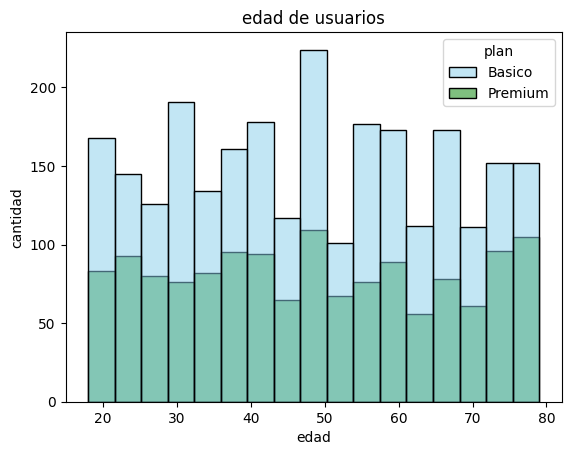

In [ ]:
# Histograma para visualizar la edad (age)
user_profile = users.merge(usage_agg, on= 'user_id', how='left')
print (user_profile.head())

sns.histplot(data= user_profile, x='age', hue='plan', palette=['skyblue','green'])
plt.title('edad de usuarios')
plt.xlabel('edad')
plt.ylabel ('cantidad')
plt.show()

💡Insights: Se muestra un comportamiento casi uniforme, excepto por un pico notable entre los 45 y 50 años.También se puede observar que entre más edad se tiene el plan cambia de básico a Premium.

- Distribución: No es una distribución normal, ni está sesgada: solo tiene un segmento claramente dominante con respecto a la edad y el tipo de plan.


   user_id first_name last_name   age      city                      reg_date  \
0    10000     Carlos    Garcia  38.0  Medellín 2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres  53.0      <NA> 2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez  57.0      CDMX 2022-01-01 13:08:35.828957239   
3    10003      Mateo   Ramirez  69.0    Bogotá 2022-01-01 19:42:53.743435858   
4    10004      Mateo    Torres  63.0       GDL 2022-01-02 02:17:11.657914478   

      plan churn_date  cant_mensajes  cant_llamadas  cant_minutos_llamada  
0   Basico        NaN            7.0            3.0                 23.70  
1   Basico        NaN            5.0           10.0                 33.18  
2   Basico        NaN            5.0            2.0                 10.74  
3  Premium        NaN           11.0            3.0                  8.99  
4   Basico        NaN            4.0            3.0                  8.01  


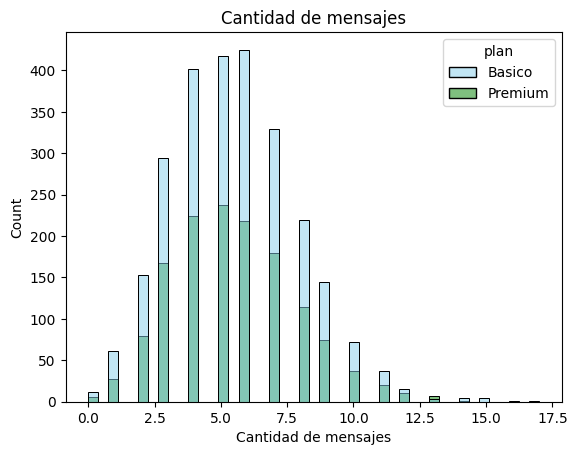

In [ ]:
# Histograma para visualizar la cant_mensajes
user_profile = users.merge(usage_agg, on= 'user_id', how='left')
print (user_profile.head())

sns.histplot(data= user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'])
plt.title('Cantidad de mensajes')
plt.xlabel('Cantidad de mensajes')
plt.show()

💡Insights:
- Se observa un sesgo a la derecha del gráfico, debido a que las cantidades de mensajes es baja para ambos planes, aunque se considera que el plan premium tiene más envio por cantidades de mensajes.
- Para ambos planes la alta cantidad de mensajes se concentran entre el rango 2.5 y 7.5; siendo 5.0 el más alto para ambos planes.

   user_id first_name last_name   age      city                      reg_date  \
0    10000     Carlos    Garcia  38.0  Medellín 2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres  53.0      <NA> 2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez  57.0      CDMX 2022-01-01 13:08:35.828957239   
3    10003      Mateo   Ramirez  69.0    Bogotá 2022-01-01 19:42:53.743435858   
4    10004      Mateo    Torres  63.0       GDL 2022-01-02 02:17:11.657914478   

      plan churn_date  cant_mensajes  cant_llamadas  cant_minutos_llamada  
0   Basico        NaN            7.0            3.0                 23.70  
1   Basico        NaN            5.0           10.0                 33.18  
2   Basico        NaN            5.0            2.0                 10.74  
3  Premium        NaN           11.0            3.0                  8.99  
4   Basico        NaN            4.0            3.0                  8.01  


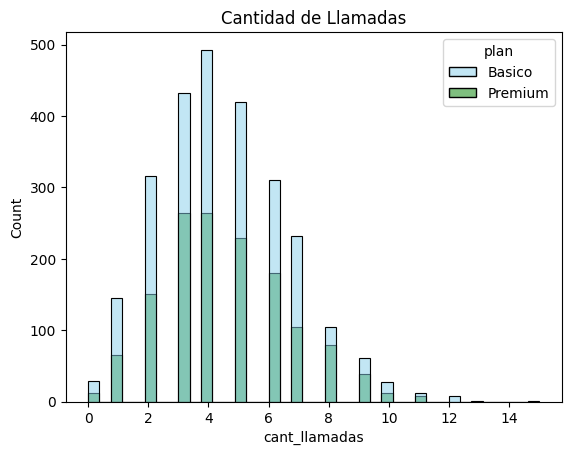

In [ ]:
# Histograma para visualizar la cant_llamadas
user_profile = users.merge(usage_agg, on= 'user_id', how='left')
print (user_profile.head())

sns.histplot(data= user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'])
plt.title('Cantidad de Llamadas')
plt.show()

💡Insights:  tiene los valores más altos concentrados entre 2 y 8 por cantidad de llamadas. Siendo la cant_llamadas 3 y 4 la más dominantemente igual y en el tipo de plan premium.
- Distribución: No es una distribución normal, hay un segmento concentrado en el rango 2 al 8, con un pequeña cola hacia la izquierda del gráfico porque hay algunos valores altos que permiten este sesgo.


   user_id first_name last_name   age      city                      reg_date  \
0    10000     Carlos    Garcia  38.0  Medellín 2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres  53.0      <NA> 2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez  57.0      CDMX 2022-01-01 13:08:35.828957239   
3    10003      Mateo   Ramirez  69.0    Bogotá 2022-01-01 19:42:53.743435858   
4    10004      Mateo    Torres  63.0       GDL 2022-01-02 02:17:11.657914478   

      plan churn_date  cant_mensajes  cant_llamadas  cant_minutos_llamada  
0   Basico        NaN            7.0            3.0                 23.70  
1   Basico        NaN            5.0           10.0                 33.18  
2   Basico        NaN            5.0            2.0                 10.74  
3  Premium        NaN           11.0            3.0                  8.99  
4   Basico        NaN            4.0            3.0                  8.01  


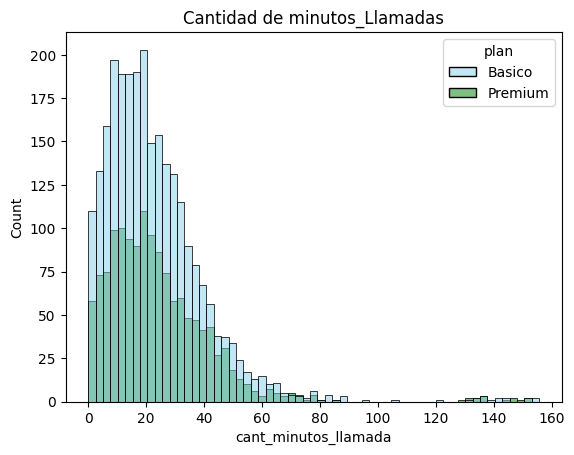

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
user_profile = users.merge(usage_agg, on= 'user_id', how='left')
print (user_profile.head())

sns.histplot(data= user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'])
plt.title('Cantidad de minutos_Llamadas')
plt.show()

💡Insights: La mayor parte de las cant_minutos_llamada están concentrados en valores bajos o medios, pero existe una pequeña porción de cantidad de minutos muy alto, lo que genera una cola hacia la derecha.

- Distribución: Es una distribución concentrada en la derecha, entre el rango 0 al 50, y comienza en el valor 55 con un pequeña cola hacia la izquierda del gráfico porque hay algunos valores altos que permiten este sesgo.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

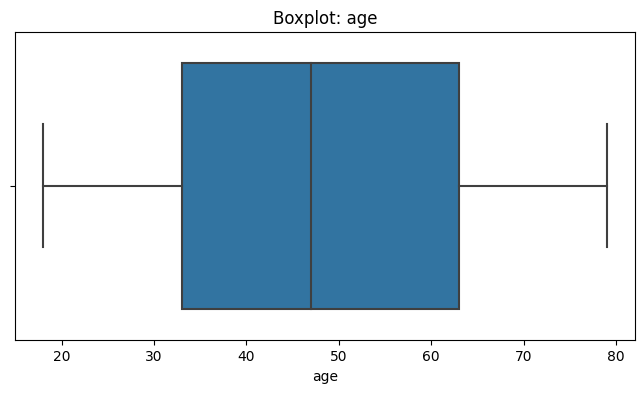

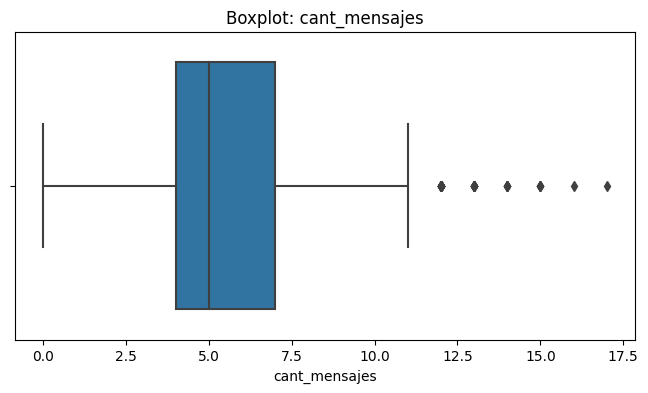

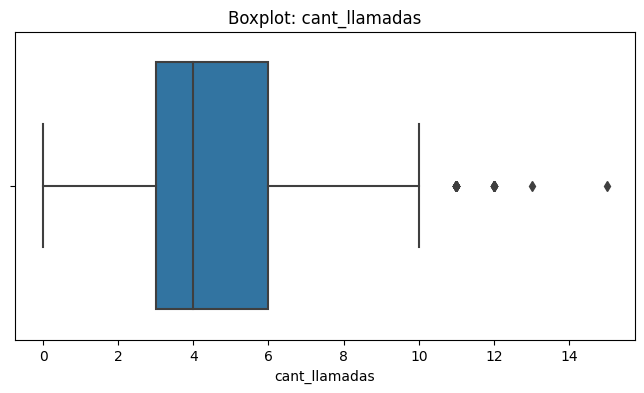

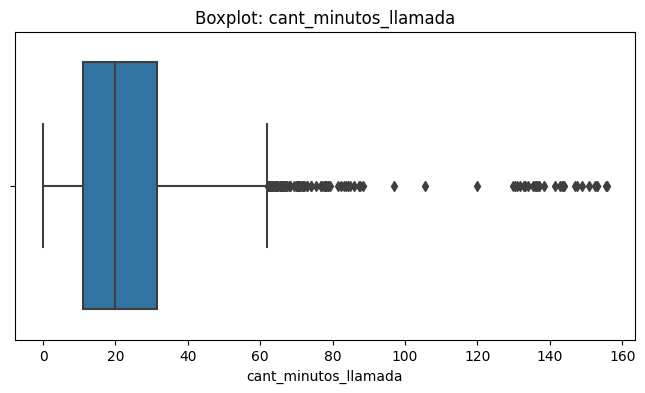

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights:
- Age: No presenta outliers
- cant_mensajes: Presenta outliers leves hacia la izquierda fuera del bigote.
- cant_llamadas: Presenta outliers leves hacia la izquierda fuera del bigote.
- cant_minutos_llamada: Presenta outliers  extremos hacia la izquierda fuera del bigote.

Primer cuartil: cant_mensajes            4.00
cant_llamadas            3.00
cant_minutos_llamada    11.12
Name: 0.25, dtype: float64
Tercer cuartil: cant_mensajes            7.000
cant_llamadas            6.000
cant_minutos_llamada    31.415
Name: 0.75, dtype: float64
IQR:  cant_mensajes            3.000
cant_llamadas            3.000
cant_minutos_llamada    20.295
dtype: float64


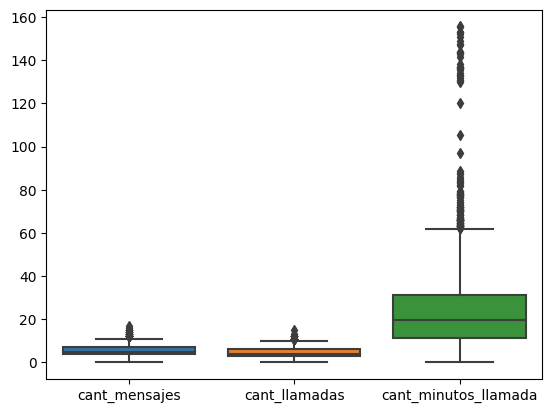

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ["cant_mensajes", "cant_llamadas","cant_minutos_llamada"]
Q1 = user_profile[columnas_limites].quantile(0.25)
print('Primer cuartil:', Q1)

#calcular Q3
Q3 =user_profile[columnas_limites].quantile(0.75)
print('Tercer cuartil:', Q3)

#calcular IQR
IQR = Q3 - Q1
print('IQR: ', IQR)

sns.boxplot(data=user_profile[columnas_limites])
plt.show()

In [ ]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener outliers, por que aunque son valores que sobrepasan el limite superior (límite superior = 25.5, max = 17), es de unas pocas cantidades, podría tratarse de una variación natural de usuarios muy activos (no necesariamente un error).
- cant_llamadas: mantener outliers, por que aunque son valores que sobrepasan el limite superior ( límite superior = 22.5, max = 15), es de unas pocas cantidades, podría tratarse de una variación natural de usuarios muy activos (no necesariamente un error).
- cant_minutos_llamada: mantener outliers, porque el limite maximo es exageradamente mayor (límite superior = 668.09, max = 155.69), es un valor atípico que distorsiona las estadísticas y se alejan significativamente del comportamiento general de los datos, pero se puede estabilizar sin perder la información.


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
def classify_segment(row):
    cant_llamadas = row["cant_llamadas"]
    cant_mensajes = row["cant_mensajes"]
    #condiciones de llamadas
    if cant_llamadas >=5:
        if cant_mensajes >=5:
            return "Bajo uso"
    elif cant_llamadas <=10:
        if cant_mensajes >=10:
            return "Uso medio"
        else:
            return "Alto uso"

user_profile["grupo_uso"] = user_profile.apply(classify_segment, axis=1)
user_profile[["cant_llamadas", "cant_mensajes", "grupo_uso"]].head()

,cant_llamadas,cant_mensajes,grupo_uso
0,3.0,7.0,Alto uso
1,10.0,5.0,Bajo uso
2,2.0,5.0,Alto uso
3,3.0,11.0,Uso medio
4,3.0,4.0,Alto uso


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_edad,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Adulto,Alto uso
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Adulto,Bajo uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Adulto,Alto uso
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Adulto Mayor,Uso medio
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Adulto Mayor,Alto uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def classify_segment(row):
     age = row["age"]

#condiciones de llamadas
     if age <30:
         return "Joven"
     elif age <60:
               return "Adulto"
     else:
            return "Adulto Mayor"

user_profile["grupo_edad"] =user_profile.apply(classify_segment, axis=1)
user_profile[["age", "grupo_edad"]].head()

,age,grupo_edad
0,38.0,Adulto
1,53.0,Adulto
2,57.0,Adulto
3,69.0,Adulto Mayor
4,63.0,Adulto Mayor


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

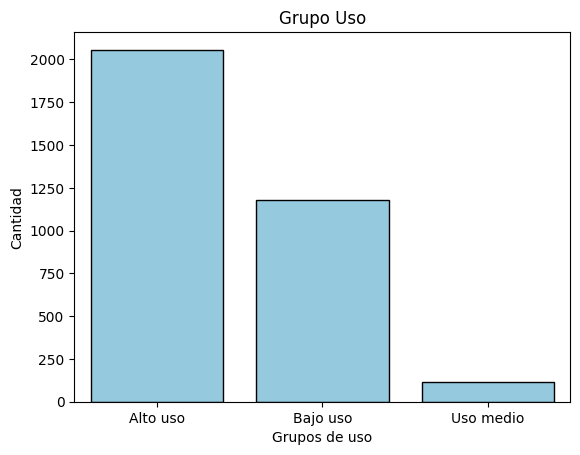

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x="grupo_uso", color='skyblue', edgecolor='black')
plt.title("Grupo Uso")
plt.xlabel("Grupos de uso")
plt.ylabel("Cantidad")
plt.show()

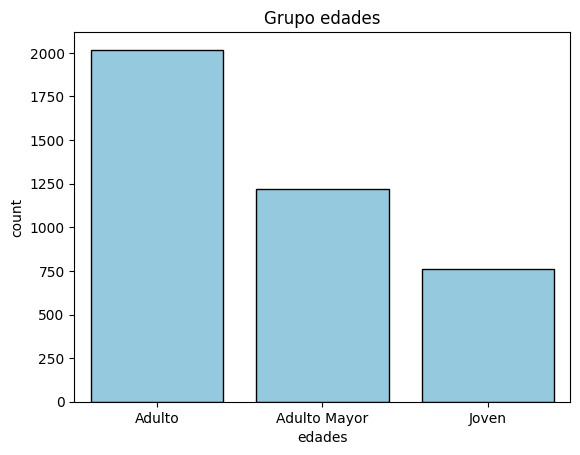

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x="grupo_edad", color='skyblue', edgecolor='black')
plt.title("Grupo edades")
plt.xlabel("edades")
plt.show()

---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- En los 2 de los 3 DF encontramos valores faltantes en columnas como “city” (469) que presenta un 11% de los datos y en la columna de “Churn_date” (3534) representando una proporción del 88%.
- Para el negocio que estos valores faltantes representan que 1 de cada 10 usuarios no se puede ubicar la ciudad donde contrataron el plan, lo que limita las campañas regionales. Para la columna “Churn_date”  que contenga 3534 vacío/nulo, probablemente significa que el cliente sigue activo y que 466 “llenos” son los que aparecen con fechas en la cual fue cancelado el servicio.

🔍 **Segmentos por Edad**
- Segmenté clientes por uso (bajo, medio y alto) basándome en la cantidad de mensajes y la cantidad de llamadas.
- Los clientes tienen un “Alto uso” (más de 10 llamadas y 10 de mensajes) que sobrepasa un poco las 2.000 cantidades, el “Uso bajo” (menos de 5 llamadas y menos de 5 mensajes), sobrepasa las 1.000 cantidades y por último, el “Uso medio” que presenta menos de 10 llamadas y menos de 10 mensajes no tiene un alcance de 250 cantidades.
- El comportamiento según la edad encontramos que el segmento de “adulto” es el que más destaca por 2.000 cantidades y representan las edades de menor a 60 años, luego le sigue “adulto mayor”, concentrado en las edades de +60 años y con uso de llamadas y mensajes cercanos a las 1.250 cantidades, y por últimos tenemos a “Joven” con uso cercano a las 750 cantidades.

📊 **Segmentos por Nivel de Uso**
- El segmento de “adultos”, ya que tiene un “Alto uso” de llamadas y mensajes cercano a las 2.000 cantidades, es decir, el 50% de los datos recolectados.

➡️ Esto sugiere que ...
- Un patrón de uso extremo en la cantidad de minutos por llamadas, lo que puede implicar para el negocio que los clientes utilizan muchos más minutos de lo normal, lo cual tendría sentido con el segmento de "alto Uso" que está por encima de las 2.000 cantidades, para connectaTel podría causar saturación de red o aumentar costos para ofrecer los planes, por consecuente implicaría un riesgo de fuga a la competencia por planes insufientes.
- Todo lo anterior, podría representar una oportunidad de negocio y no solo un riesgo, ya que estos clientes que demuestran que tienen un alto uso y que son en su mayoría adultos y adultos mayor, es decir, tienen un alto poder adquisitivo para contratar un plan premium y que cubran su consumo.  


💡 **Recomendaciones**
- Se identificó que el segmento "adulto" con "alto uso" es el más valioso, por representar mayores ingresos al negocio, por lo cual le ofrecería a este grupo para fidelizarlo o hacer upselling, por ejemplo, más minutos, beneficios extra, descuentos por permanencia.
- Además, observamos que tenemos un segmento de "uso bajo" con más de 1.000 clientes, es una buena cifra para ofertar un plan más económico y ajustado a su consumo real, y así evitar que cancelen por sentir que pagan de más.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`